In [1]:
# ==========================
# CELL 2 — IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
# =====================
# CELL 3 — LOAD DATA
# =====================

data = pd.read_csv("iris_clustering.csv")
data.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

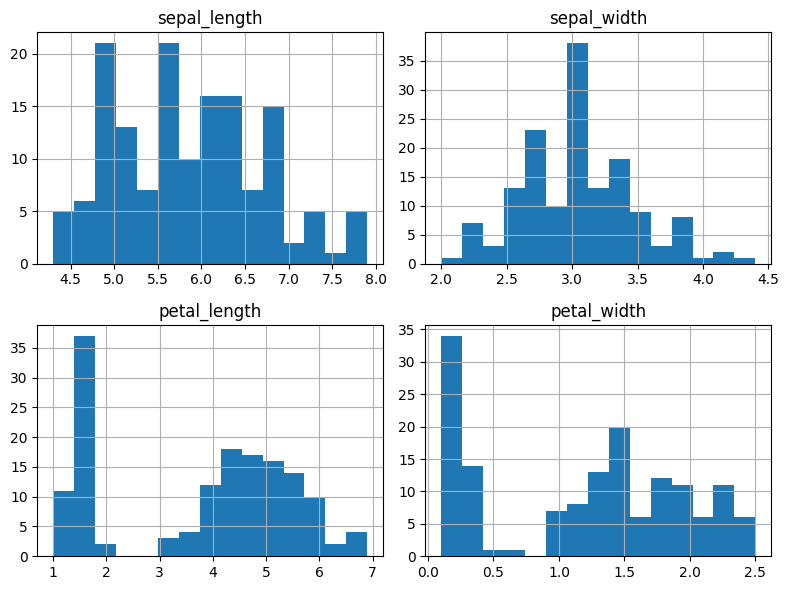

In [3]:
# =====================
# CELL 4 — BASIC EDA
# =====================

print(data.info())
print(data.describe())
print("Missing Values:\n", data.isnull().sum())

data.hist(figsize=(8,6), bins=15)
plt.tight_layout()
plt.show()


In [4]:
# ==================================
# CELL 5 — FEATURE / TARGET SPLIT
# ==================================

target = data['species']
features = data.drop(columns=['species'])


In [5]:
# ==========================
# CELL 6 — FEATURE SCALING
# ==========================

scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(features),
    columns=features.columns
)

scaled_features.head()


,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [6]:
# ==========================
# CELL 7 — KMEANS CLUSTERING
# ==========================

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(scaled_features)

scaled_features['KMeans_Cluster'] = kmeans_clusters
scaled_features.head()


,sepal_length,sepal_width,petal_length,petal_width,KMeans_Cluster
0,-0.900681,1.032057,-1.341272,-1.312977,1
1,-1.143017,-0.124958,-1.341272,-1.312977,2
2,-1.385353,0.337848,-1.398138,-1.312977,2
3,-1.506521,0.106445,-1.284407,-1.312977,2
4,-1.021849,1.263460,-1.341272,-1.312977,1


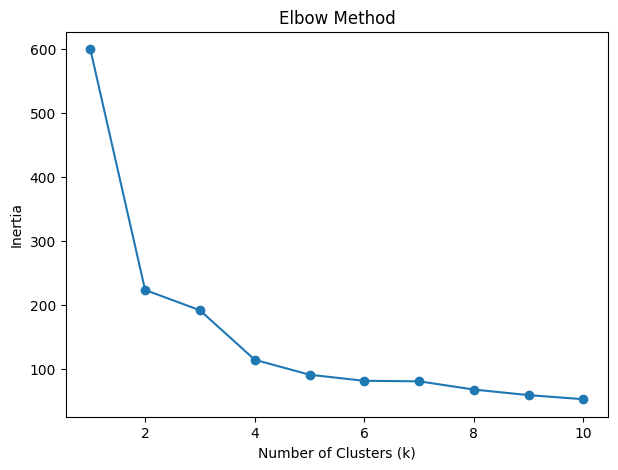

In [7]:
# ==========================
# CELL 8 — ELBOW METHOD
# ==========================

inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features.iloc[:, :-1])
    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


In [8]:
# ==========================
# CELL 9 — SILHOUETTE SCORE
# ==========================

sil_score = silhouette_score(
    scaled_features.iloc[:, :-1],
    scaled_features['KMeans_Cluster']
)

print("Silhouette Score (KMeans):", sil_score)


Silhouette Score (KMeans): 0.4787241921049546


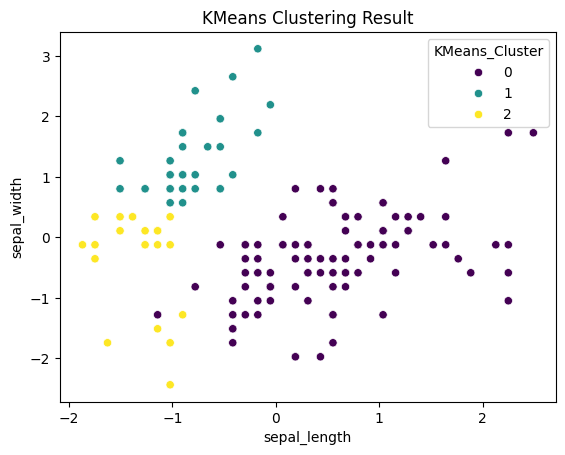

In [9]:
# ==========================
# CELL 10 — VISUALIZATION (KMEANS)
# ==========================

sns.scatterplot(
    x=scaled_features.iloc[:, 0],
    y=scaled_features.iloc[:, 1],
    hue=scaled_features['KMeans_Cluster'],
    palette="viridis"
)

plt.title("KMeans Clustering Result")
plt.show()


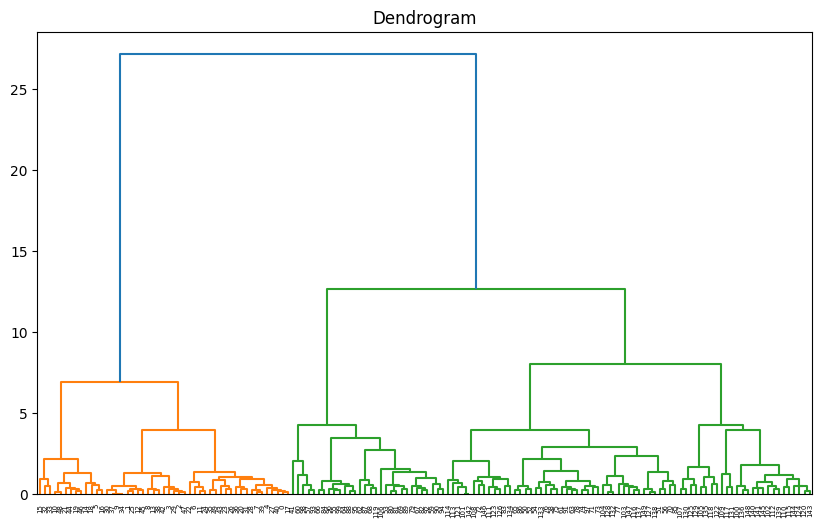

In [10]:
# ==================================
# CELL 11 — HIERARCHICAL CLUSTERING
# ==================================

linked = linkage(scaled_features.iloc[:, :-1], method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

agg = AgglomerativeClustering(n_clusters=3)
agg_clusters = agg.fit_predict(scaled_features.iloc[:, :-1])

scaled_features['Hierarchical_Cluster'] = agg_clusters


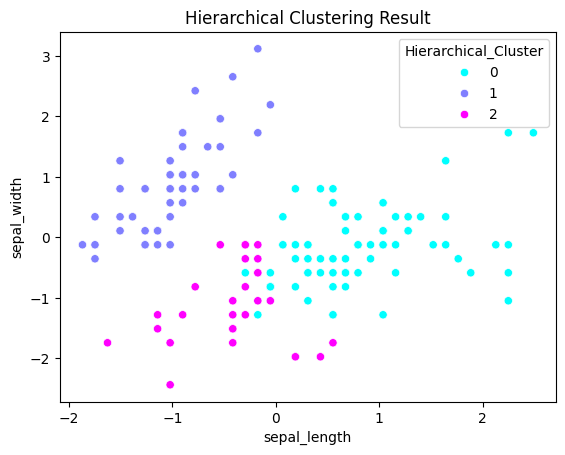

In [11]:
# ==================================
# CELL 12 — VISUALIZATION (HIERARCHICAL)
# ==================================

sns.scatterplot(
    x=scaled_features.iloc[:, 0],
    y=scaled_features.iloc[:, 1],
    hue=scaled_features['Hierarchical_Cluster'],
    palette="cool"
)

plt.title("Hierarchical Clustering Result")
plt.show()


In [12]:
# ==================================
# CELL 13 — CLUSTER EVALUATION
# ==================================

numeric_cols = features.columns

sil_kmeans = silhouette_score(
    scaled_features[numeric_cols],
    scaled_features['KMeans_Cluster']
)

sil_hier = silhouette_score(
    scaled_features[numeric_cols],
    scaled_features['Hierarchical_Cluster']
)

db_kmeans = davies_bouldin_score(
    scaled_features[numeric_cols],
    scaled_features['KMeans_Cluster']
)

db_hier = davies_bouldin_score(
    scaled_features[numeric_cols],
    scaled_features['Hierarchical_Cluster']
)

ari_kmeans = adjusted_rand_score(
    target,
    scaled_features['KMeans_Cluster']
)

ari_hier = adjusted_rand_score(
    target,
    scaled_features['Hierarchical_Cluster']
)

print("Silhouette (KMeans):", sil_kmeans)
print("Silhouette (Hierarchical):", sil_hier)
print("Davies-Bouldin (KMeans):", db_kmeans)
print("Davies-Bouldin (Hierarchical):", db_hier)
print("Adjusted Rand Index (KMeans):", ari_kmeans)
print("Adjusted Rand Index (Hierarchical):", ari_hier)


Silhouette (KMeans): 0.4787241921049546
Silhouette (Hierarchical): 0.44553956399200406
Davies-Bouldin (KMeans): 0.7868006762339902
Davies-Bouldin (Hierarchical): 0.805940469032997
Adjusted Rand Index (KMeans): 0.4289511167236898
Adjusted Rand Index (Hierarchical): 0.6153229932145449
